# Week 3 - Day 12
# Decision Tree Classification using Iris Dataset

**Cooperative Tech Private Limited AI/ML Internship**

## Objective
- Learn Decision Tree Classification
- Train and evaluate a model
- Visualize the tree
- Save plots for GitHub README


## Import Libraries

In [4]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

os.makedirs("../images", exist_ok=True)


## Load Dataset

In [11]:
df = pd.read_csv("../data/iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Dataset Information

In [12]:
print(df.shape)
df.info()
df.describe().T

(150, 6)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


,count,mean,std,min,25%,50%,75%,max
Id,150.0,75.500000,43.445368,1.0,38.25,75.50,112.75,150.0
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.10,5.80,6.40,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.80,3.00,3.30,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.60,4.35,5.10,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.30,1.30,1.80,2.5


## Missing Values

In [13]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

## Species Distribution

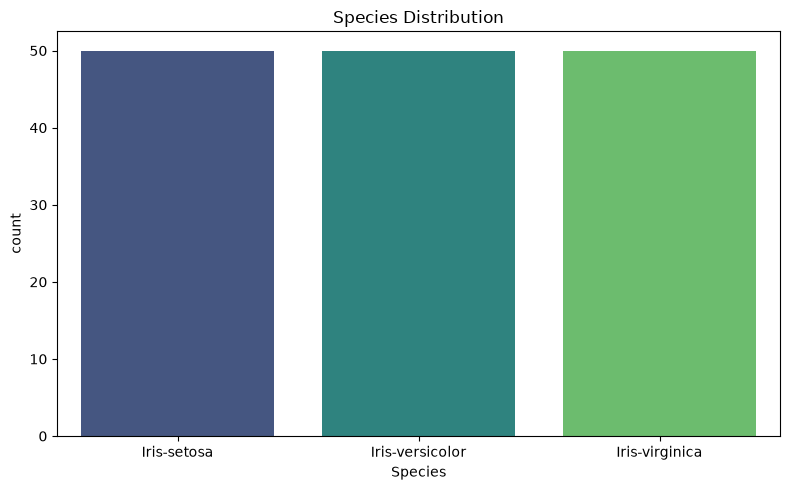

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Species",palette="viridis")
plt.title("Species Distribution")
plt.tight_layout()
plt.savefig("../images/species_distribution_decision_tree.png",dpi=300)
plt.show()

## Correlation Heatmap

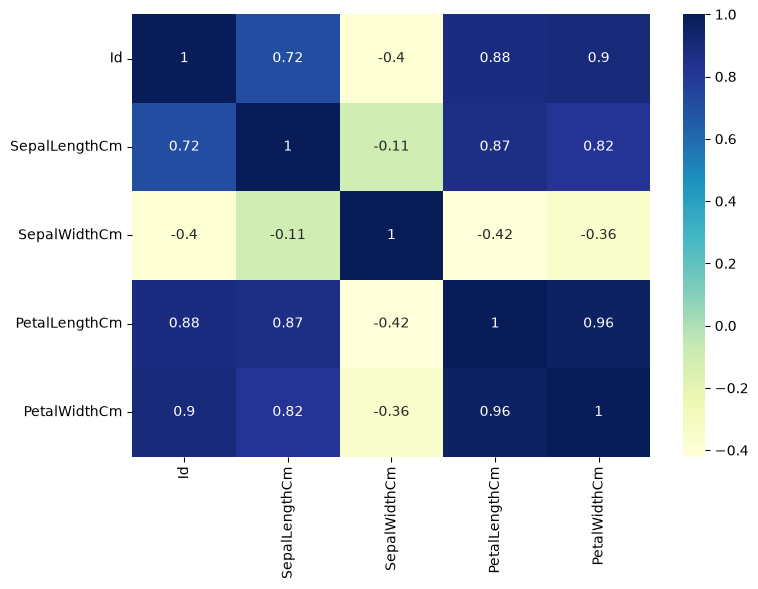

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=["Species"]).corr(),annot=True,cmap="YlGnBu")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png",dpi=300)
plt.show()

## Feature Selection

In [16]:
X=df.drop(columns=["Id","Species"])
y=df["Species"]

## Train Test Split

In [17]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

## Train Decision Tree

In [18]:
model=DecisionTreeClassifier(max_depth=5,criterion="gini",random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

## Prediction

In [19]:
y_pred=model.predict(X_test)

## Accuracy

In [20]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9333333333333333


## Classification Report

In [21]:
print(classification_report(y_test,y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



## Confusion Matrix

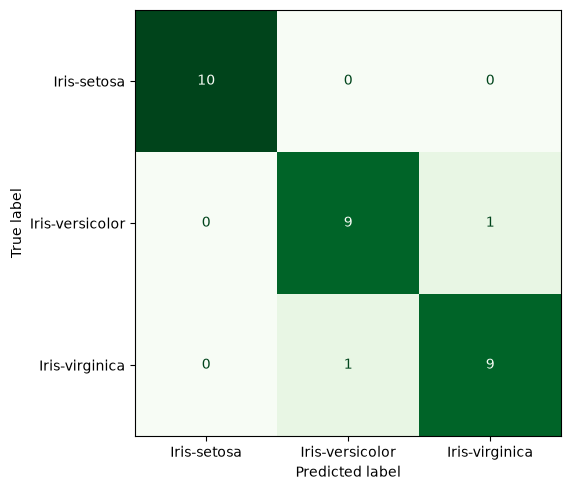

In [22]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
fig,ax=plt.subplots(figsize=(6,5))
disp.plot(ax=ax,cmap="Greens",colorbar=False)
plt.tight_layout()
plt.savefig("../images/confusion_matrix_decision_tree.png",dpi=300)
plt.show()

## Decision Tree Visualization

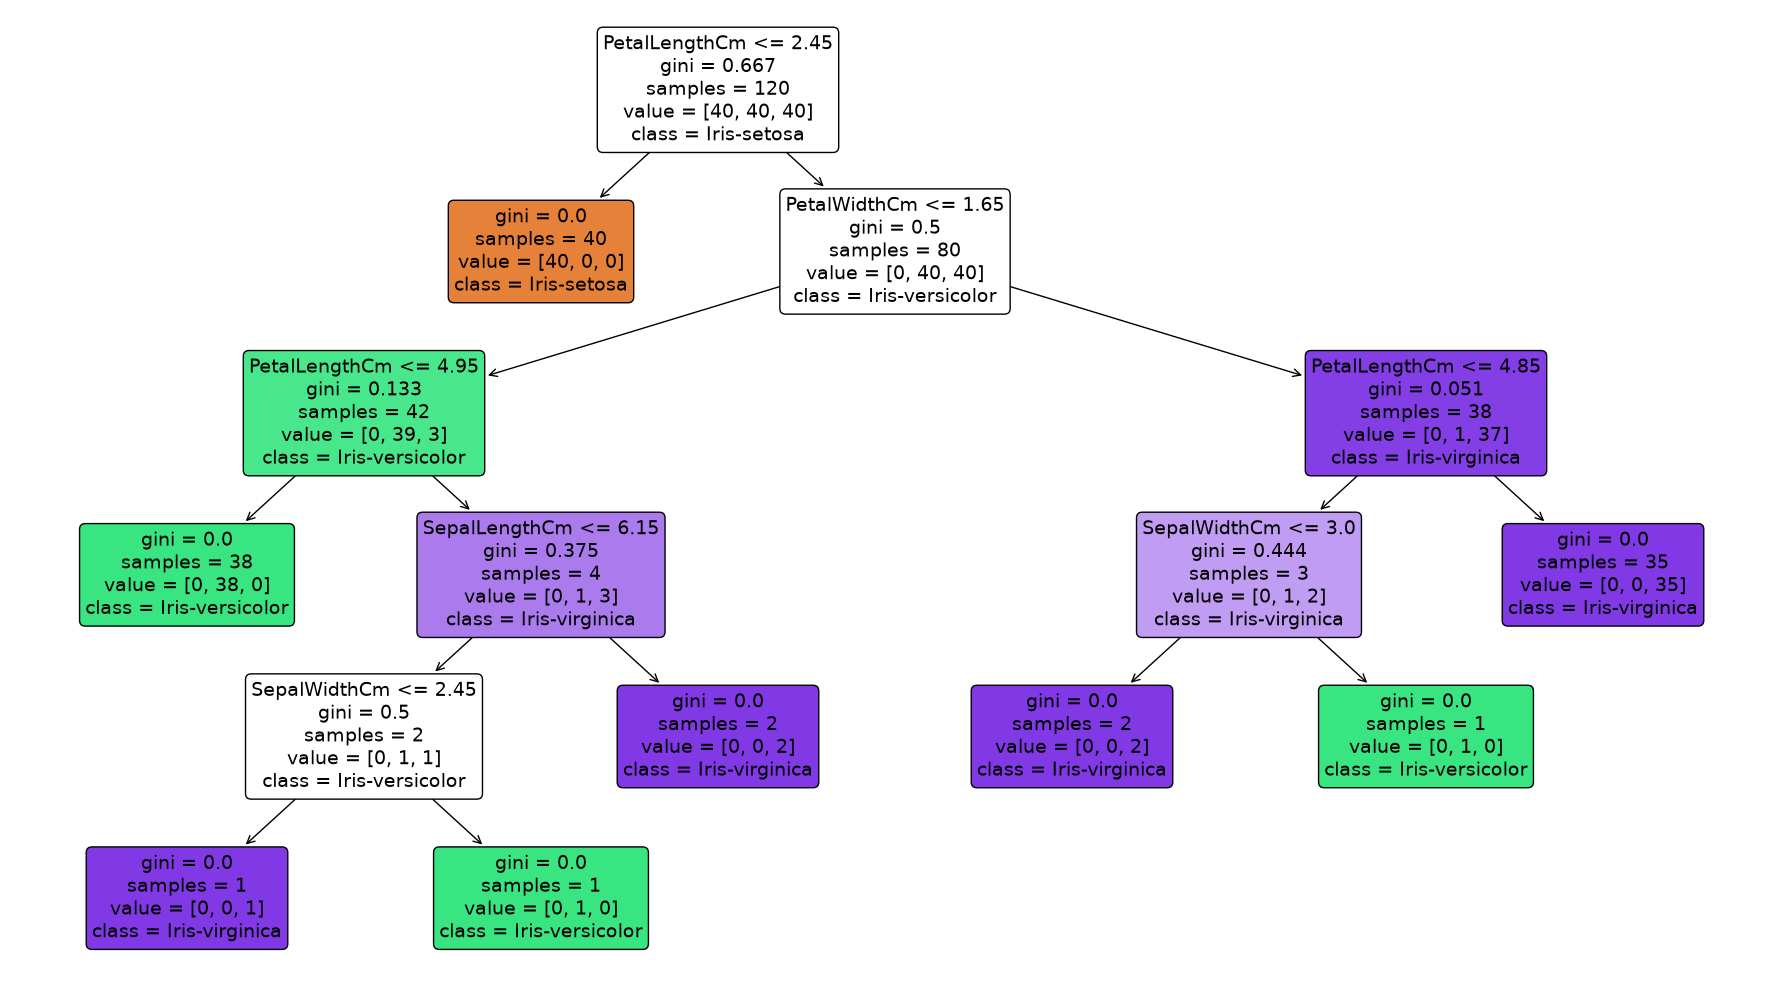

In [23]:
plt.figure(figsize=(18,10))
plot_tree(model,feature_names=X.columns,class_names=model.classes_,filled=True,rounded=True)
plt.tight_layout()
plt.savefig("../images/decision_tree_visualization.png",dpi=300)
plt.show()

## Feature Importance

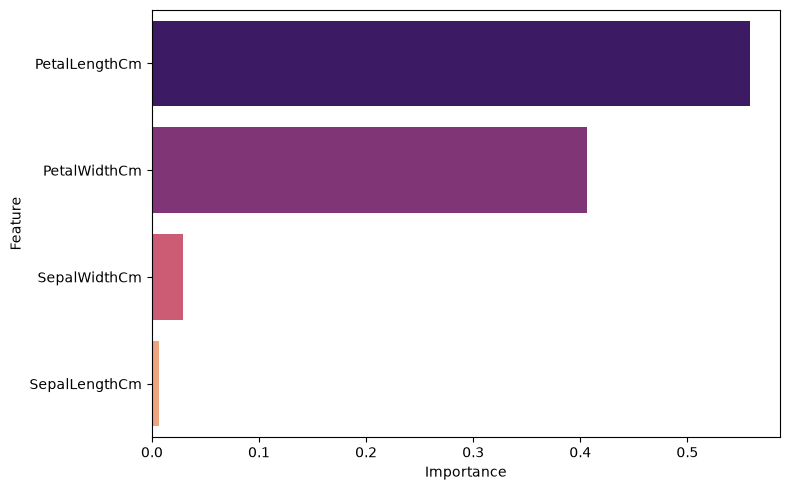

,Feature,Importance
2,PetalLengthCm,0.558568
3,PetalWidthCm,0.406015
1,SepalWidthCm,0.029167
0,SepalLengthCm,0.006250


In [24]:
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
}).sort_values("Importance",ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance,x="Importance",y="Feature",palette="magma")
plt.tight_layout()
plt.savefig("../images/feature_importance.png",dpi=300)
plt.show()
importance

## Tree Information

In [25]:
print("Tree Depth:",model.get_depth())
print("Leaves:",model.get_n_leaves())

Tree Depth: 5
Leaves: 8


## Conclusion

This notebook demonstrated Decision Tree Classification on the Iris Dataset.
The workflow included:
- Data loading
- Data exploration
- Model training
- Evaluation
- Confusion Matrix
- Decision Tree visualization
- Feature Importance

Saved images:
- species_distribution_decision_tree.png
- correlation_heatmap.png
- confusion_matrix_decision_tree.png
- decision_tree_visualization.png
- feature_importance.png
